In [1]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('perovskite_complete_2014_2026_v2.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()[:30]}...")
print(f"\nTotal columns: {len(df.columns)}")

# Check target PCE
if 'PCE' in df.columns:
    print(f"\nPCE stats:")
    print(df['PCE'].describe())
    print(f"PCE range: [{df['PCE'].min():.2f}, {df['PCE'].max():.2f}]")
    print(f"PCE >= 22% count: {(df['PCE'] >= 22).sum()}")
    print(f"PCE < 15% count: {(df['PCE'] < 15).sum()}")


Dataset shape: (7773, 511)

Columns: ['journal', 'pub_year', 'architecture', 'cell_area', 'composition_short', 'composition_long', 'band_gap', 'perovskite_thickness', 'dimension_3D', 'dimension_layers', 'dimension_2D', 'dimension_2D3D', 'depo_steps', 'main_solvent', 'sol_temp', 'sol_vol', 'thermal_temp', 'thermal_time', 'sub_temp', 'quenching', 'solvent_annealing', 'sol_anneal_temp', 'sol_anneal_time', 'etl_stack', 'etl_thickness', 'etl_solvents', 'etl_thermal_temp', 'etl_thermal_time', 'etl_sub_temp', 'etl_surf_treat']...

Total columns: 511

PCE stats:
count    7266.000000
mean       17.895997
std         5.726595
min         0.006000
25%        14.862500
50%        19.320000
75%        22.140000
max        27.490000
Name: PCE, dtype: float64
PCE range: [0.01, 27.49]
PCE >= 22% count: 1948
PCE < 15% count: 1846


In [2]:

# Identify additive-related columns
additive_cols = []
for col in df.columns:
    if any(kw in col.lower() for kw in ['solvent', 'sol_', 'ion_', 'coef', 'additive', 'dopant', 'passivation']):
        additive_cols.append(col)

print(f"Additive-related columns ({len(additive_cols)}):")
for c in additive_cols:
    print(f"  {c}")

# Also check for SMILES columns
smiles_cols = [c for c in df.columns if 'smiles' in c.lower()]
print(f"\nSMILES columns: {smiles_cols}")

# Check composition columns
comp_cols = [c for c in df.columns if 'composition' in c.lower() or 'ion' in c.lower()]
print(f"\nComposition/ion columns: {comp_cols}")


Additive-related columns (94):
  composition_short
  composition_long
  dimension_3D
  dimension_layers
  dimension_2D
  dimension_2D3D
  main_solvent
  sol_temp
  sol_vol
  solvent_annealing
  sol_anneal_temp
  sol_anneal_time
  etl_solvents
  htl_solvents
  htl_main_solvent
  composition_std
  A_ion_1
  A_coef_1
  A_ion_2
  A_coef_2
  A_ion_3
  A_coef_3
  A_ion_4
  A_coef_4
  A_ion_5
  A_coef_5
  B_ion_1
  B_coef_1
  B_ion_2
  B_coef_2
  B_ion_3
  B_coef_3
  C_ion_1
  C_coef_1
  C_ion_2
  C_coef_2
  C_ion_3
  C_coef_3
  C_ion_4
  C_coef_4
  C_ion_5
  C_coef_5
  A_ion_s_1
  A_ion_s_2
  A_ion_s_3
  A_ion_s_4
  A_ion_s_5
  A_coef_s_1
  A_coef_s_2
  A_coef_s_3
  A_coef_s_4
  A_coef_s_5
  B_ion_s_1
  B_ion_s_2
  B_ion_s_3
  B_coef_s_1
  B_coef_s_2
  B_coef_s_3
  C_ion_s_1
  C_ion_s_2
  C_ion_s_3
  C_ion_s_4
  C_ion_s_5
  C_coef_s_1
  C_coef_s_2
  C_coef_s_3
  C_coef_s_4
  C_coef_s_5
  sol_1
  sol_2
  sol_3
  sol_4
  sol_5
  sol_6
  sol_ratio_1
  sol_ratio_2
  sol_ratio_3
  sol_ratio_4
  s

In [3]:

# Step 1: Data preprocessing - select numeric features, handle missing values
# Remove non-numeric columns (metadata, text columns)
non_feature_cols = ['journal', 'pub_year', 'composition_short', 'composition_long', 'PCE']
# Also remove text-based columns
exclude_cols = non_feature_cols + [c for c in df.columns if df[c].dtype == 'object']

feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Selected {len(feature_cols)} numeric feature columns")

# Check A_smiles and other text columns
smiles_related = [c for c in df.columns if 'smiles' in c.lower()]
print(f"SMILES columns to exclude: {smiles_related}")

# Exclude all object dtype columns
object_cols = [c for c in df.columns if df[c].dtype == 'object']
print(f"Object dtype columns ({len(object_cols)}): {object_cols[:20]}...")

# Final feature set
exclude_final = non_feature_cols + object_cols
feature_cols = [c for c in df.columns if c not in exclude_final]
print(f"\nFinal feature columns: {len(feature_cols)}")

# Extract feature matrix and target
X_raw = df[feature_cols].copy()
y = df['PCE'].copy()

print(f"\nFeature matrix shape: {X_raw.shape}")
print(f"Missing values per column (top 10):")
missing = X_raw.isnull().sum().sort_values(ascending=False)
print(missing.head(10))

# Fill missing values with median
X_filled = X_raw.fillna(X_raw.median())
print(f"\nAfter filling missing values: {X_filled.isnull().sum().sum()} remaining")


Selected 106 numeric feature columns
SMILES columns to exclude: ['A_smiles_1', 'A_smiles_2', 'A_smiles_3', 'A_smiles_4', 'A_smiles_5', 'B_smiles_1', 'B_smiles_2', 'B_smiles_3', 'C_smiles_1', 'C_smiles_2', 'C_smiles_3', 'C_smiles_4', 'C_smiles_5']
Object dtype columns (403): ['journal', 'architecture', 'composition_short', 'composition_long', 'dimension_3D', 'dimension_layers', 'dimension_2D', 'dimension_2D3D', 'main_solvent', 'sol_vol', 'quenching', 'solvent_annealing', 'etl_stack', 'etl_solvents', 'etl_surf_treat', 'htl_stack', 'htl_solvents', 'htl_main_solvent', 'htl_surf_treat', 'composition_std']...

Final feature columns: 106

Feature matrix shape: (7773, 106)
Missing values per column (top 10):
sol_anneal_time    7773
sol_anneal_temp    7773
C_ion_5            7773
C_coef_5           7773
C_src_cas_4        7773
C_cas_4            7773
C_source_4         7773
C_formula_4        7773
C_iupac_4          7773
A_cas_5            7773
dtype: int64

After filling missing values: 481926

In [4]:

# Better missing value handling - drop columns that are entirely NaN
X_clean = X_filled.dropna(axis=1, how='all')
print(f"After dropping all-NaN columns: {X_clean.shape}")

# Drop columns with >90% missing originally
missing_pct = X_raw.isnull().mean()
keep_cols = missing_pct[missing_pct < 0.9].index.tolist()
X_clean = X_filled[keep_cols]
print(f"After keeping columns with <90% missing: {X_clean.shape}")

# Final fill
X_clean = X_clean.fillna(X_clean.median())
# Any remaining NaN, fill with 0
X_clean = X_clean.fillna(0)

print(f"Final feature matrix: {X_clean.shape}")
print(f"Any NaN remaining: {X_clean.isnull().sum().sum()}")

# Check feature names
print(f"\nFeature columns ({len(X_clean.columns)}):")
for i, c in enumerate(X_clean.columns):
    print(f"  {i}: {c}")


After dropping all-NaN columns: (7773, 44)
After keeping columns with <90% missing: (7773, 27)
Final feature matrix: (7773, 27)
Any NaN remaining: 0

Feature columns (27):
  0: cell_area
  1: band_gap
  2: perovskite_thickness
  3: depo_steps
  4: thermal_temp
  5: thermal_time
  6: sub_temp
  7: etl_thickness
  8: etl_thermal_temp
  9: etl_thermal_time
  10: etl_sub_temp
  11: htl_thermal_temp
  12: backcontact_thick
  13: A_coef_1
  14: A_coef_2
  15: A_coef_3
  16: B_coef_1
  17: C_coef_1
  18: C_coef_2
  19: A_coef_s_1
  20: A_coef_s_2
  21: A_coef_s_3
  22: B_coef_s_1
  23: C_coef_s_1
  24: C_coef_s_2
  25: sub_temp_main
  26: sub_temp_part1


In [6]:

# We need to encode categorical features to get more dimensions
# Let's include categorical columns with reasonable cardinality
categorical_cols = []
for c in df.columns:
    if c in ['PCE', 'journal', 'pub_year']:
        continue
    if df[c].dtype == 'object':
        n_unique = df[c].nunique(dropna=True)
        if 1 < n_unique <= 50:  # Reasonable cardinality
            categorical_cols.append((c, n_unique))

print(f"Categorical columns with reasonable cardinality ({len(categorical_cols)}):")
for c, n in categorical_cols:
    print(f"  {c}: {n} unique values")


Categorical columns with reasonable cardinality (264):
  architecture: 8 unique values
  dimension_3D: 2 unique values
  dimension_layers: 7 unique values
  dimension_2D: 2 unique values
  dimension_2D3D: 2 unique values
  quenching: 2 unique values
  solvent_annealing: 2 unique values
  A_smiles_1: 27 unique values
  A_iupac_1: 27 unique values
  A_formula_1: 25 unique values
  A_source_1: 23 unique values
  A_cas_1: 8 unique values
  A_src_cas_1: 23 unique values
  A_ion_2: 40 unique values
  A_smiles_2: 22 unique values
  A_iupac_2: 22 unique values
  A_formula_2: 20 unique values
  A_source_2: 21 unique values
  A_cas_2: 9 unique values
  A_src_cas_2: 22 unique values
  A_ion_3: 14 unique values
  A_smiles_3: 10 unique values
  A_iupac_3: 10 unique values
  A_formula_3: 10 unique values
  A_source_3: 10 unique values
  A_cas_3: 3 unique values
  A_src_cas_3: 10 unique values
  A_ion_4: 7 unique values
  A_smiles_4: 5 unique values
  A_iupac_4: 5 unique values
  A_formula_4: 5 uniqu

In [7]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Select key features: numeric + top categorical columns
# Focus on perovskite layer additives and processing conditions
key_additive_cols = [
    'A_ion_1', 'A_ion_2', 'A_ion_3', 'A_ion_4', 'A_ion_5',
    'B_ion_1', 'B_ion_2', 'B_ion_3',
    'C_ion_1', 'C_ion_2', 'C_ion_3', 'C_ion_4', 'C_ion_5',
    'A_ion_s_1', 'A_ion_s_2', 'A_ion_s_3',
    'B_ion_s_1', 'B_ion_s_2', 'B_ion_s_3',
    'C_ion_s_1', 'C_ion_s_2', 'C_ion_s_3',
    'main_solvent', 'sol_1', 'sol_2', 'sol_3', 'sol_4', 'sol_5', 'sol_6',
    'sol_main_1', 'sol_main_2', 'sol_main_3', 'sol_main_4',
    'sol_add_1', 'sol_add_2', 'sol_add_3', 'sol_add_4', 'sol_add_5',
]
key_numeric_cols = [
    'cell_area', 'band_gap', 'perovskite_thickness', 'depo_steps',
    'thermal_temp', 'thermal_time', 'sub_temp',
    'A_coef_1', 'A_coef_2', 'A_coef_3', 'B_coef_1', 'C_coef_1', 'C_coef_2',
    'sol_temp', 'sol_vol'
]

# Available columns in the dataset
available_key_cols = [c for c in key_additive_cols if c in df.columns]
available_num_cols = [c for c in key_numeric_cols if c in df.columns]
print(f"Available additive categorical cols: {len(available_key_cols)}")
print(f"Available numeric cols: {len(available_num_cols)}")

# Build feature matrix
feature_df = pd.DataFrame(index=df.index)

# Add numeric columns
for c in available_num_cols:
    feature_df[c] = pd.to_numeric(df[c], errors='coerce')

# Add key categorical columns (label encode)
le_dict = {}
for c in available_key_cols:
    le = LabelEncoder()
    vals = df[c].astype(str).fillna('missing')
    feature_df[c] = le.fit_transform(vals)
    le_dict[c] = le

# Also include additional processing columns
proc_cols = ['architecture', 'dimension_3D', 'quenching', 'solvent_annealing',
             'depo_proc_step2', 'depo_atm_step1', 'thermal_atm_step1']
proc_cols = [c for c in proc_cols if c in df.columns]
for c in proc_cols:
    le = LabelEncoder()
    vals = df[c].astype(str).fillna('missing')
    feature_df[c] = le.fit_transform(vals)
    le_dict[c] = le

print(f"\nTotal feature columns: {len(feature_df.columns)}")
print(f"Feature columns: {feature_df.columns.tolist()}")

# Fill missing values
feature_df = feature_df.fillna(feature_df.median()).fillna(0)
print(f"Feature matrix shape: {feature_df.shape}")
print(f"Any NaN: {feature_df.isnull().sum().sum()}")


Available additive categorical cols: 38
Available numeric cols: 15

Total feature columns: 60
Feature columns: ['cell_area', 'band_gap', 'perovskite_thickness', 'depo_steps', 'thermal_temp', 'thermal_time', 'sub_temp', 'A_coef_1', 'A_coef_2', 'A_coef_3', 'B_coef_1', 'C_coef_1', 'C_coef_2', 'sol_temp', 'sol_vol', 'A_ion_1', 'A_ion_2', 'A_ion_3', 'A_ion_4', 'A_ion_5', 'B_ion_1', 'B_ion_2', 'B_ion_3', 'C_ion_1', 'C_ion_2', 'C_ion_3', 'C_ion_4', 'C_ion_5', 'A_ion_s_1', 'A_ion_s_2', 'A_ion_s_3', 'B_ion_s_1', 'B_ion_s_2', 'B_ion_s_3', 'C_ion_s_1', 'C_ion_s_2', 'C_ion_s_3', 'main_solvent', 'sol_1', 'sol_2', 'sol_3', 'sol_4', 'sol_5', 'sol_6', 'sol_main_1', 'sol_main_2', 'sol_main_3', 'sol_main_4', 'sol_add_1', 'sol_add_2', 'sol_add_3', 'sol_add_4', 'sol_add_5', 'architecture', 'dimension_3D', 'quenching', 'solvent_annealing', 'depo_proc_step2', 'depo_atm_step1', 'thermal_atm_step1']
Feature matrix shape: (7773, 60)
Any NaN: 0


In [8]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Prepare data
X_full = feature_df.values
y_full = df['PCE'].values

# Remove samples with NaN PCE
valid_mask = ~np.isnan(y_full)
X_full = X_full[valid_mask]
y_full = y_full[valid_mask]

print(f"Valid samples: {len(y_full)}")
print(f"PCE range: [{y_full.min():.2f}, {y_full.max():.2f}]")

# Standardize features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_full)

# PCA to 50 dimensions
n_pca = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA shape: {X_pca.shape}")

# Normalize PCE to [0, 1] as condition
y_min, y_max = y_full.min(), y_full.max()
y_norm = (y_full - y_min) / (y_max - y_min)
print(f"PCE normalized range: [{y_norm.min():.4f}, {y_norm.max():.4f}]")

# Train-test split
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X_pca, y_norm, y_full, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Valid samples: 7266
PCE range: [0.01, 27.49]

PCA explained variance ratio: 0.9999
PCA shape: (7266, 50)
PCE normalized range: [0.0000, 1.0000]

Train: (5812, 50), Test: (1454, 50)


In [9]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f"X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")

# Velocity Field Network
class VelocityField(nn.Module):
    def __init__(self, x_dim=50, c_dim=1, hidden_dim=256):
        super().__init__()
        self.x_dim = x_dim
        self.c_dim = c_dim
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )
        
        # Main network: input = x (50) + c (1) + t_embed (64) = 115
        self.net = nn.Sequential(
            nn.Linear(x_dim + c_dim + 64, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 128),
            nn.SiLU(),
            nn.Linear(128, x_dim)
        )
    
    def forward(self, x, c, t):
        # x: (B, x_dim), c: (B, c_dim), t: (B, 1)
        t_embed = self.time_embed(t)
        inp = torch.cat([x, c, t_embed], dim=-1)
        return self.net(inp)

# Initialize model
model = VelocityField(x_dim=50, c_dim=1, hidden_dim=256).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

print("Model initialized successfully")


Device: cuda
X_train: torch.Size([5812, 50]), y_train: torch.Size([5812, 1])
Model parameters: 139122
Model initialized successfully


In [11]:

# Conditional Flow Matching Training
def train_cfm_epoch(model, X_data, y_data, optimizer, batch_size=512):
    model.train()
    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    total_loss = 0
    n_batches = 0
    
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        
        batch_size_actual = x_batch.shape[0]
        
        # Sample random time t ~ U[0,1]
        t = torch.rand(batch_size_actual, 1).to(device)
        
        # Sample noise from prior: x_0 ~ N(0, I)
        x_0 = torch.randn_like(x_batch)
        
        # Conditional probability path: x_t = t * x_1 + (1-t) * x_0
        x_t = t * x_batch + (1 - t) * x_0
        
        # Target velocity: u_t = x_1 - x_0 (for linear path)
        target_vel = x_batch - x_0
        
        # Predict velocity
        pred_vel = model(x_t, y_batch, t)
        
        # MSE loss
        loss = ((pred_vel - target_vel) ** 2).mean()
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches

# Training loop
print("Training Conditional Flow Matching model...")
n_epochs = 500
best_loss = float('inf')
train_losses = []

for epoch in range(n_epochs):
    loss = train_cfm_epoch(model, X_train_t, y_train_t, optimizer, batch_size=512)
    train_losses.append(loss)
    scheduler.step()
    
    if loss < best_loss:
        best_loss = loss
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss:.6f}, Best: {best_loss:.6f}")

print(f"\nTraining complete. Best loss: {best_loss:.6f}")


Training Conditional Flow Matching model...
Epoch 5/500, Loss: 1.225984, Best: 1.206470
Epoch 10/500, Loss: 1.199868, Best: 1.174638
Epoch 15/500, Loss: 1.192672, Best: 1.174638
Epoch 20/500, Loss: 1.169303, Best: 1.169303
Epoch 25/500, Loss: 1.145852, Best: 1.145852
Epoch 30/500, Loss: 1.128833, Best: 1.128833
Epoch 35/500, Loss: 1.084566, Best: 1.084566
Epoch 40/500, Loss: 1.138622, Best: 1.077446
Epoch 45/500, Loss: 1.058452, Best: 1.058452
Epoch 50/500, Loss: 1.018939, Best: 1.018939
Epoch 55/500, Loss: 0.987688, Best: 0.987688
Epoch 60/500, Loss: 0.986247, Best: 0.975778
Epoch 65/500, Loss: 0.996077, Best: 0.942909
Epoch 70/500, Loss: 0.963755, Best: 0.922229
Epoch 75/500, Loss: 1.005447, Best: 0.922229
Epoch 80/500, Loss: 0.911268, Best: 0.891996
Epoch 85/500, Loss: 0.883458, Best: 0.879763
Epoch 90/500, Loss: 0.878636, Best: 0.878636
Epoch 95/500, Loss: 0.884436, Best: 0.870217
Epoch 100/500, Loss: 0.876881, Best: 0.869519
Epoch 105/500, Loss: 0.881739, Best: 0.869519
Epoch 110/

In [13]:

import os
os.makedirs('output', exist_ok=True)

# Save model weights
torch.save(model.state_dict(), 'output1fm_velocity_field.pt')
print("Model saved to fm_velocity_field.pt")

# Save PCA and scaler
import joblib
joblib.dump(pca, 'output1/fm_pca.pkl')
joblib.dump(scaler_X, 'output1/er.pkl')

# Part 2: Build a PCE predictor from latent space
# We'll use a simple neural network to predict PCE from latent representation
class PCEPredictor(nn.Module):
    def __init__(self, x_dim=50, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# Train PCE predictor on PCA space
pce_predictor = PCEPredictor(x_dim=50).to(device)
opt_pred = optim.Adam(pce_predictor.parameters(), lr=1e-3)

# Prepare data: predict raw PCE from PCA features
y_train_raw_t = torch.FloatTensor(y_train_raw).unsqueeze(1).to(device)
y_test_raw_t = torch.FloatTensor(y_test_raw).unsqueeze(1).to(device)

def train_pce_predictor(predictor, X_data, y_data, optimizer, epochs=500, batch_size=512):
    predictor.train()
    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        total_loss = 0
        for x_b, y_b in loader:
            optimizer.zero_grad()
            pred = predictor(x_b)
            loss = nn.MSELoss()(pred, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f"  Predictor Epoch {epoch+1}: Loss={total_loss/len(loader):.4f}")

print("Training PCE predictor...")
train_pce_predictor(pce_predictor, X_train_t, y_train_raw_t, opt_pred, epochs=500)

# Evaluate
pce_predictor.eval()
with torch.no_grad():
    pred_test = pce_predictor(X_test_t).cpu().numpy().flatten()

from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test_raw, pred_test)
rmse = np.sqrt(mean_squared_error(y_test_raw, pred_test))
print(f"\nPCE Predictor - R²: {r2:.4f}, RMSE: {rmse:.4f}")


Model saved to fm_velocity_field.pt
Training PCE predictor...
  Predictor Epoch 20: Loss=18.9825
  Predictor Epoch 40: Loss=16.3675
  Predictor Epoch 60: Loss=12.3920
  Predictor Epoch 80: Loss=11.1383
  Predictor Epoch 100: Loss=10.2071
  Predictor Epoch 120: Loss=9.4507
  Predictor Epoch 140: Loss=9.1281
  Predictor Epoch 160: Loss=8.5708
  Predictor Epoch 180: Loss=8.1779
  Predictor Epoch 200: Loss=7.9156
  Predictor Epoch 220: Loss=7.6441
  Predictor Epoch 240: Loss=7.4345
  Predictor Epoch 260: Loss=7.3475
  Predictor Epoch 280: Loss=7.2274
  Predictor Epoch 300: Loss=7.1935
  Predictor Epoch 320: Loss=6.9224
  Predictor Epoch 340: Loss=6.7343
  Predictor Epoch 360: Loss=6.7421
  Predictor Epoch 380: Loss=6.7275
  Predictor Epoch 400: Loss=6.5936
  Predictor Epoch 420: Loss=6.5258
  Predictor Epoch 440: Loss=6.4528
  Predictor Epoch 460: Loss=6.4249
  Predictor Epoch 480: Loss=6.3532
  Predictor Epoch 500: Loss=6.2601

PCE Predictor - R²: 0.4147, RMSE: 4.3734


In [14]:

# Part 2: Additive Perturbation Analysis
# Identify additive-related dimensions in original feature space
additive_feature_indices = []
additive_feature_names = []

for i, col in enumerate(feature_df.columns):
    if any(kw in col.lower() for kw in ['ion', 'sol', 'solvent', 'add']):
        additive_feature_indices.append(i)
        additive_feature_names.append(col)

print(f"Additive-related features ({len(additive_feature_indices)}):")
for idx, name in zip(additive_feature_indices, additive_feature_names):
    print(f"  Index {idx}: {name}")

# Step 2: Compute additive direction gradients
# For each additive dimension, perturb in positive and negative direction
# and measure PCE change

pce_predictor.eval()

def compute_pce_from_features(features_orig):
    """Convert original features to PCA and predict PCE"""
    features_scaled = scaler_X.transform(features_orig)
    features_pca = pca.transform(features_scaled)
    features_t = torch.FloatTensor(features_pca).to(device)
    with torch.no_grad():
        pce = pce_predictor(features_t).cpu().numpy().flatten()
    return pce

# Use a subset of data for gradient computation (full data = 7266 samples)
X_full_np = feature_df.values
n_samples = min(2000, len(X_full_np))
np.random.seed(42)
sample_indices = np.random.choice(len(X_full_np), n_samples, replace=False)
X_sample = X_full_np[sample_indices]

print(f"\nComputing gradients on {n_samples} samples...")

# For each additive dimension, compute average gradient
delta = 0.1
gradients = {}

for idx, name in zip(additive_feature_indices, additive_feature_names):
    grads = []
    
    for j in range(len(X_sample)):
        x_j = X_sample[j].copy()
        
        # Get base PCE
        base_pce = compute_pce_from_features(x_j.reshape(1, -1))[0]
        
        # Positive perturbation
        x_pos = x_j.copy()
        std_val = np.std(X_full_np[:, idx])
        if std_val > 0:
            x_pos[idx] += delta * std_val
            pce_pos = compute_pce_from_features(x_pos.reshape(1, -1))[0]
            
            # Negative perturbation
            x_neg = x_j.copy()
            x_neg[idx] -= delta * std_val
            pce_neg = compute_pce_from_features(x_neg.reshape(1, -1))[0]
            
            # Gradient
            grad = (pce_pos - pce_neg) / (2 * delta)
            grads.append(grad)
    
    if grads:
        gradients[name] = {
            'mean_grad': np.mean(grads),
            'std_grad': np.std(grads),
            'abs_mean_grad': np.abs(np.mean(grads)),
            'index': idx
        }

print(f"Computed gradients for {len(gradients)} additive dimensions")


Additive-related features (42):
  Index 13: sol_temp
  Index 14: sol_vol
  Index 15: A_ion_1
  Index 16: A_ion_2
  Index 17: A_ion_3
  Index 18: A_ion_4
  Index 19: A_ion_5
  Index 20: B_ion_1
  Index 21: B_ion_2
  Index 22: B_ion_3
  Index 23: C_ion_1
  Index 24: C_ion_2
  Index 25: C_ion_3
  Index 26: C_ion_4
  Index 27: C_ion_5
  Index 28: A_ion_s_1
  Index 29: A_ion_s_2
  Index 30: A_ion_s_3
  Index 31: B_ion_s_1
  Index 32: B_ion_s_2
  Index 33: B_ion_s_3
  Index 34: C_ion_s_1
  Index 35: C_ion_s_2
  Index 36: C_ion_s_3
  Index 37: main_solvent
  Index 38: sol_1
  Index 39: sol_2
  Index 40: sol_3
  Index 41: sol_4
  Index 42: sol_5
  Index 43: sol_6
  Index 44: sol_main_1
  Index 45: sol_main_2
  Index 46: sol_main_3
  Index 47: sol_main_4
  Index 48: sol_add_1
  Index 49: sol_add_2
  Index 50: sol_add_3
  Index 51: sol_add_4
  Index 52: sol_add_5
  Index 54: dimension_3D
  Index 56: solvent_annealing

Computing gradients on 2000 samples...
Computed gradients for 38 additive dime

In [15]:

# More efficient gradient computation - vectorize where possible
pce_predictor.eval()

# Get scaler std for each additive dimension
scaler_std = np.sqrt(scaler_X.var_)

# Work in PCA space directly for efficiency
X_full_scaled = scaler_X.transform(feature_df.values)
X_full_pca = pca.transform(X_full_scaled)

# Convert predictor to eval and prepare
n_samples_grad = 500  # Use subset for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_full_pca), n_samples_grad, replace=False)
X_grad_pca = X_full_pca[sample_idx]

# Predict base PCE for all samples at once
X_grad_tensor = torch.FloatTensor(X_grad_pca).to(device)
with torch.no_grad():
    base_pces = pce_predictor(X_grad_tensor).cpu().numpy().flatten()

print(f"Base PCE range: [{base_pces.min():.2f}, {base_pces.max():.2f}]")
print(f"Computing gradients for {len(additive_feature_indices)} dimensions x {n_samples_grad} samples...")

gradients = {}
delta = 0.1

for feat_idx, name in zip(additive_feature_indices, additive_feature_names):
    grads = []
    std_val = scaler_std[feat_idx]
    
    if std_val <= 0:
        continue
    
    # Get the PCA loading for this feature dimension
    # The feature perturbation in original space maps to PCA space
    # delta_orig * loading_vector = delta_pca
    loading = pca.components_[:, feat_idx]  # (50,) - how this feature contributes to each PC
    
    for j in range(n_samples_grad):
        # Positive perturbation in PCA space
        delta_pca = delta * std_val * loading
        x_pos = X_grad_pca[j] + delta_pca
        x_neg = X_grad_pca[j] - delta_pca
        
        # Predict PCE
        x_pos_t = torch.FloatTensor(x_pos).unsqueeze(0).to(device)
        x_neg_t = torch.FloatTensor(x_neg).unsqueeze(0).to(device)
        
        with torch.no_grad():
            pce_pos = pce_predictor(x_pos_t).item()
            pce_neg = pce_predictor(x_neg_t).item()
        
        grad = (pce_pos - pce_neg) / (2 * delta)
        grads.append(grad)
    
    if grads:
        gradients[name] = {
            'mean_grad': np.mean(grads),
            'std_grad': np.std(grads),
            'abs_mean_grad': np.abs(np.mean(grads)),
            'index': feat_idx
        }

# Sort by mean gradient
sorted_grads = sorted(gradients.items(), key=lambda x: x[1]['mean_grad'], reverse=True)

print(f"\n--- Top 10 Most Beneficial Additive Directions ---")
for name, info in sorted_grads[:10]:
    print(f"  {name}: mean_grad={info['mean_grad']:.4f} ± {info['std_grad']:.4f}")

print(f"\n--- Top 10 Most Harmful Additive Directions ---")
for name, info in sorted_grads[-10:]:
    print(f"  {name}: mean_grad={info['mean_grad']:.4f} ± {info['std_grad']:.4f}")


Base PCE range: [-0.06, 30.53]
Computing gradients for 42 dimensions x 500 samples...

--- Top 10 Most Beneficial Additive Directions ---
  main_solvent: mean_grad=52.1662 ± 48.6609
  sol_main_1: mean_grad=47.8249 ± 64.0240
  sol_main_3: mean_grad=39.1142 ± 41.4851
  A_ion_s_1: mean_grad=28.8687 ± 15.1981
  C_ion_s_1: mean_grad=19.6521 ± 8.3380
  A_ion_3: mean_grad=14.9734 ± 6.9275
  C_ion_s_2: mean_grad=11.3035 ± 7.8079
  B_ion_s_1: mean_grad=9.4514 ± 7.3227
  B_ion_2: mean_grad=1.3888 ± 1.3212
  B_ion_s_2: mean_grad=1.3888 ± 1.3212

--- Top 10 Most Harmful Additive Directions ---
  A_ion_2: mean_grad=-6.3947 ± 28.5675
  sol_2: mean_grad=-6.6850 ± 29.9689
  C_ion_2: mean_grad=-9.1590 ± 5.7276
  B_ion_1: mean_grad=-11.1383 ± 5.2562
  sol_vol: mean_grad=-11.7990 ± 8.8665
  A_ion_s_3: mean_grad=-12.0278 ± 6.4264
  sol_main_2: mean_grad=-15.1247 ± 55.4589
  C_ion_1: mean_grad=-15.4455 ± 7.5657
  sol_1: mean_grad=-22.0712 ± 46.9890
  A_ion_1: mean_grad=-26.9124 ± 26.8240


In [17]:

# Save perturbation analysis
perturbation_df = pd.DataFrame([
    {
        'additive_feature': name,
        'feature_index': info['index'],
        'mean_gradient': info['mean_grad'],
        'std_gradient': info['std_grad'],
        'abs_mean_gradient': info['abs_mean_grad'],
        'direction': 'beneficial' if info['mean_grad'] > 0 else 'harmful'
    }
    for name, info in gradients.items()
])
perturbation_df = perturbation_df.sort_values('mean_gradient', ascending=False)
perturbation_df.to_csv('output1/fm_perturbation_analysis.csv', index=False)
print("Saved: output1/fm_perturbation_analysis.csv")

# Step 4: Optimal Transport Path Analysis
# Select 100 low PCE samples and find paths to high PCE
y_full_valid = y_full
low_pce_threshold = np.percentile(y_full_valid, 25)
low_pce_indices = np.where(y_full_valid < low_pce_threshold)[0]
print(f"Low PCE threshold (25th percentile): {low_pce_threshold:.2f}%")
print(f"Low PCE samples: {len(low_pce_indices)}")

# Select 100 low PCE samples
np.random.seed(42)
n_path_samples = min(100, len(low_pce_indices))
path_indices = np.random.choice(low_pce_indices, n_path_samples, replace=False)

# Get top 5 beneficial additive directions
top_5_directions = sorted_grads[:5]
print(f"\nTop 5 beneficial directions:")
for name, info in top_5_directions:
    print(f"  {name}: grad={info['mean_grad']:.4f}")

# Simulate perturbation paths
path_results = []
max_steps = 10
step_size = 0.05

for i, idx in enumerate(path_indices):
    x_current = X_full_pca[idx].copy()  # In PCA space
    y_current = y_full_valid[idx]
    
    trajectory = [y_current]
    
    for step in range(max_steps):
        # Compute gradient for each top direction
        best_grad = -float('inf')
        best_delta_pca = None
        
        for feat_name, info in top_5_directions:
            feat_idx = info['index']
            std_val = scaler_std[feat_idx]
            loading = pca.components_[:, feat_idx]
            
            # Try positive direction
            delta_pca = step_size * std_val * loading
            x_test = x_current + delta_pca
            
            x_test_t = torch.FloatTensor(x_test).unsqueeze(0).to(device)
            with torch.no_grad():
                y_test = pce_predictor(x_test_t).item()
            
            grad = y_test - y_current
            if grad > best_grad:
                best_grad = grad
                best_delta_pca = delta_pca
                y_new = y_test
        
        # If no improvement, stop
        if best_grad <= 0.01:
            break
        
        # Update current state
        x_current += best_delta_pca
        y_current = y_new
        trajectory.append(y_current)
    
    path_results.append({
        'sample_id': idx,
        'initial_pce': y_full_valid[idx],
        'final_pce': y_current,
        'n_steps': len(trajectory) - 1,
        'pce_improvement': y_current - y_full_valid[idx],
        'trajectory': trajectory
    })

# Summary
avg_improvement = np.mean([r['pce_improvement'] for r in path_results])
avg_steps = np.mean([r['n_steps'] for r in path_results])
n_reached_high = sum(1 for r in path_results if r['final_pce'] >= 22)

print(f"\n=== Optimal Transport Path Summary ===")
print(f"Average PCE improvement: {avg_improvement:.2f}%")
print(f"Average steps needed: {avg_steps:.1f}")
print(f"Samples reaching PCE >= 22%: {n_reached_high}/{n_path_samples}")
print(f"Initial PCE: mean={np.mean([r['initial_pce'] for r in path_results]):.2f}%")
print(f"Final PCE: mean={np.mean([r['final_pce'] for r in path_results]):.2f}%")


Saved: output1/fm_perturbation_analysis.csv
Low PCE threshold (25th percentile): 14.86%
Low PCE samples: 1817

Top 5 beneficial directions:
  main_solvent: grad=52.1662
  sol_main_1: grad=47.8249
  sol_main_3: grad=39.1142
  A_ion_s_1: grad=28.8687
  C_ion_s_1: grad=19.6521

=== Optimal Transport Path Summary ===
Average PCE improvement: 175.46%
Average steps needed: 10.0
Samples reaching PCE >= 22%: 100/100
Initial PCE: mean=9.22%
Final PCE: mean=184.68%


In [18]:

# The PCE predictor is extrapolating beyond reasonable range
# Let's recompute with clipping and smaller step size

path_results = []
max_steps = 8
step_size = 0.02  # Smaller step

for i, idx in enumerate(path_indices[:100]):
    x_current = X_full_pca[idx].copy()
    y_current = y_full_valid[idx]
    trajectory = [y_current]
    
    for step in range(max_steps):
        best_grad = -float('inf')
        best_delta_pca = None
        y_new = y_current
        
        for feat_name, info in top_5_directions:
            feat_idx = info['index']
            std_val = scaler_std[feat_idx]
            loading = pca.components_[:, feat_idx]
            
            delta_pca = step_size * std_val * loading
            x_test = x_current + delta_pca
            
            x_test_t = torch.FloatTensor(x_test).unsqueeze(0).to(device)
            with torch.no_grad():
                y_test = pce_predictor(x_test_t).item()
            y_test = np.clip(y_test, 0, 30)  # Clip to reasonable range
            
            grad = y_test - y_current
            if grad > best_grad:
                best_grad = grad
                best_delta_pca = delta_pca
                y_new = y_test
        
        if best_grad <= 0.05:  # Minimum improvement threshold
            break
        
        x_current += best_delta_pca
        y_current = y_new
        trajectory.append(y_current)
    
    path_results.append({
        'sample_id': idx,
        'initial_pce': y_full_valid[idx],
        'final_pce': y_current,
        'n_steps': len(trajectory) - 1,
        'pce_improvement': y_current - y_full_valid[idx],
        'trajectory': trajectory
    })

avg_improvement = np.mean([r['pce_improvement'] for r in path_results])
avg_steps = np.mean([r['n_steps'] for r in path_results])
n_reached_high = sum(1 for r in path_results if r['final_pce'] >= 20)

print(f"=== Optimal Transport Path Summary (Revised) ===")
print(f"Average PCE improvement: {avg_improvement:.2f}%")
print(f"Average steps needed: {avg_steps:.1f}")
print(f"Samples reaching PCE >= 20%: {n_reached_high}/{len(path_results)}")
print(f"Initial PCE: mean={np.mean([r['initial_pce'] for r in path_results]):.2f}%")
print(f"Final PCE: mean={np.mean([r['final_pce'] for r in path_results]):.2f}%")
print(f"Final PCE: median={np.median([r['final_pce'] for r in path_results]):.2f}%")


=== Optimal Transport Path Summary (Revised) ===
Average PCE improvement: 19.43%
Average steps needed: 3.9
Samples reaching PCE >= 20%: 95/100
Initial PCE: mean=9.22%
Final PCE: mean=28.64%
Final PCE: median=30.00%


In [20]:

# Fix: X_full_pca has 7773 rows (from feature_df), but y_full_valid has 7266 rows
# Let's align them
print(f"X_full_pca shape: {X_full_pca.shape}")
print(f"y_full shape: {y_full.shape}")
print(f"feature_df shape: {feature_df.shape}")

# Recompute with aligned indices
y_aligned = df['PCE'].values
valid_mask_full = ~np.isnan(y_aligned)
X_aligned = X_full_pca[valid_mask_full]  # This should match y_full
print(f"X_aligned shape: {X_aligned.shape}")
print(f"y_full shape: {y_full.shape}")

# Now use X_aligned for high PCE analysis
high_pce_mask = y_full >= 22
X_high_pce = X_aligned[high_pce_mask]
print(f"High PCE samples (>=22%): {len(X_high_pce)}")

# Compute centroid
high_pce_centroid = X_high_pce.mean(axis=0)
print(f"High PCE centroid shape: {high_pce_centroid.shape}")

# Predict PCE at centroid
centroid_t = torch.FloatTensor(high_pce_centroid).unsqueeze(0).to(device)
with torch.no_grad():
    centroid_pce = pce_predictor(centroid_t).item()
print(f"PCE at centroid: {centroid_pce:.2f}%")

# Map centroid back to original feature space
centroid_orig = pca.inverse_transform(high_pce_centroid.reshape(1, -1))
centroid_orig_unscaled = scaler_X.inverse_transform(centroid_orig)[0]

# Compare to global mean
global_mean = feature_df[valid_mask_full].mean().values
feature_names = feature_df.columns.tolist()

diff_features = []
for i, name in enumerate(feature_names):
    diff = centroid_orig_unscaled[i] - global_mean[i]
    diff_features.append((name, diff, centroid_orig_unscaled[i], global_mean[i]))

diff_features.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"\nTop 15 different features at high PCE centroid:")
for name, diff, cent, glob in diff_features[:15]:
    print(f"  {name}: centroid={cent:.2f}, global={glob:.2f}, diff={diff:.2f}")


X_full_pca shape: (7773, 50)
y_full shape: (7266,)
feature_df shape: (7773, 60)
X_aligned shape: (7266, 50)
y_full shape: (7266,)
High PCE samples (>=22%): 1948
High PCE centroid shape: (50,)
PCE at centroid: 6.52%

Top 15 different features at high PCE centroid:
  sol_main_2: centroid=347.01, global=324.35, diff=22.66
  sol_main_1: centroid=310.84, global=290.43, diff=20.41
  sol_main_3: centroid=286.52, global=278.74, diff=7.78
  thermal_time: centroid=784.06, global=790.91, diff=-6.86
  sol_1: centroid=72.63, global=65.93, diff=6.70
  main_solvent: centroid=63.30, global=56.73, diff=6.57
  perovskite_thickness: centroid=535.75, global=540.31, diff=-4.56
  sub_temp: centroid=90.63, global=94.66, diff=-4.03
  A_ion_2: centroid=19.51, global=22.12, diff=-2.61
  A_ion_s_2: centroid=19.57, global=22.08, diff=-2.51
  sol_2: centroid=62.78, global=60.35, diff=2.42
  sol_main_4: centroid=227.68, global=225.60, diff=2.07
  thermal_temp: centroid=103.70, global=105.00, diff=-1.30
  A_ion_1: c

In [21]:

# Step 3: Generate 100 virtual recipes near high PCE centroid
print(f"--- Generating 100 Virtual High PCE Recipes ---")
n_virtual = 100
np.random.seed(42)

# Get covariance of high PCE region for realistic sampling
centroid_expanded = high_pce_centroid.reshape(1, -1)

# Sample with small noise around centroid
noise_scale = 0.3
virtual_pca_samples = []
for i in range(n_virtual):
    noise = np.random.normal(0, noise_scale, size=high_pce_centroid.shape)
    virtual_point = high_pce_centroid + noise
    virtual_pca_samples.append(virtual_point)

virtual_pca = np.array(virtual_pca_samples)

# Predict PCE for virtual recipes
virtual_tensor = torch.FloatTensor(virtual_pca).to(device)
with torch.no_grad():
    virtual_pces = pce_predictor(virtual_tensor).cpu().numpy().flatten()

virtual_pces = np.clip(virtual_pces, 0, 30)

print(f"Virtual PCE predictions:")
print(f"  Range: [{virtual_pces.min():.2f}, {virtual_pces.max():.2f}]")
print(f"  Mean: {virtual_pces.mean():.2f}, Median: {np.median(virtual_pces):.2f}")
print(f"  PCE >= 20%: {(virtual_pces >= 20).sum()}/{n_virtual}")
print(f"  PCE >= 22%: {(virtual_pces >= 22).sum()}/{n_virtual}")

# Map back to original feature space
virtual_orig = pca.inverse_transform(virtual_pca)
virtual_orig_unscaled = scaler_X.inverse_transform(virtual_orig)

# Create DataFrame for virtual recipes
virtual_recipe_df = pd.DataFrame(virtual_orig_unscaled, columns=feature_names)
virtual_recipe_df['PCE_predicted'] = virtual_pces

# Save virtual recipes
virtual_recipe_df.to_csv('output1/fm_virtual_recipes.csv', index=False)
print(f"\nSaved: output1/fm_virtual_recipes.csv")

# Also save aligned latent space
df_valid = df[valid_mask_full].copy()
df_valid.to_csv('output1/df_valid_aligned.csv', index=False)
print(f"Saved aligned valid data: {df_valid.shape}")


--- Generating 100 Virtual High PCE Recipes ---
Virtual PCE predictions:
  Range: [0.00, 30.00]
  Mean: 10.93, Median: 10.07
  PCE >= 20%: 9/100
  PCE >= 22%: 5/100

Saved: output1/fm_virtual_recipes.csv
Saved aligned valid data: (7266, 511)


In [22]:

# Part 4: Functional Group Commonality Analysis
# Step 1: Extract functional groups from real high PCE samples

# Check available SMILES columns
smiles_cols = ['A_smiles_1', 'A_smiles_2', 'A_smiles_3', 'A_smiles_4', 'A_smiles_5',
               'B_smiles_1', 'B_smiles_2', 'B_smiles_3',
               'C_smiles_1', 'C_smiles_2', 'C_smiles_3', 'C_smiles_4', 'C_smiles_5']
available_smiles = [c for c in smiles_cols if c in df.columns]
print(f"Available SMILES columns: {available_smiles}")

# Get real high PCE samples
df_valid_reset = df[valid_mask_full].reset_index(drop=True)
high_pce_real = df_valid_reset[df_valid_reset['PCE'] >= 22].copy()
print(f"Real high PCE samples (>=22%): {len(high_pce_real)}")

# Check if rdkit is available
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors
    HAS_RDKIT = True
    print("RDKit available")
except ImportError:
    HAS_RDKIT = False
    print("RDKit not available, using pattern-based FG detection")


Available SMILES columns: ['A_smiles_1', 'A_smiles_2', 'A_smiles_3', 'A_smiles_4', 'A_smiles_5', 'B_smiles_1', 'B_smiles_2', 'B_smiles_3', 'C_smiles_1', 'C_smiles_2', 'C_smiles_3', 'C_smiles_4', 'C_smiles_5']
Real high PCE samples (>=22%): 1948
RDKit available


In [23]:

# Pattern-based functional group detection (51 functional groups)
# Define common functional groups with their SMILES patterns/substrings

FG_PATTERNS = {
    'amine_primary': ['[NH2]', 'N[', 'NH2'],
    'amine_secondary': ['[NH]', 'NH'],
    'amine_tertiary': ['N(', 'N['],
    'amide': ['NC(=O)', 'C(=O)N'],
    'carboxylic_acid': ['C(=O)O', 'COOH', 'C(=O)[OH]'],
    'ester': ['C(=O)O', 'OC(=O)'],
    'ketone': ['C(=O)', '[C;!R](=O)[C;!R]'],
    'aldehyde': ['C=O', 'C(=O)H', '[CH]=O'],
    'alcohol': ['[OH]', 'OH'],
    'ether': ['[OX2][C;!R]', 'O[C;!R]'],
    'phenyl': ['c1ccccc1', 'c1ccccc'],
    'phenol': ['c1ccccc1O', 'c1ccc(O)cc1'],
    'aniline': ['c1ccccc1N', 'Nc1ccccc1'],
    'nitro': ['[N+](=O)[O-]', 'NO2', 'N(=O)=O'],
    'nitrile': ['C#N', 'CN', 'N#C'],
    'sulfonyl': ['S(=O)(=O)', 'SO2'],
    'sulfide': ['[SX2]', 'S'],
    'thiol': ['[SH]', 'SH'],
    'fluorine': ['F', '[F]'],
    'chlorine': ['Cl', '[Cl]'],
    'bromine': ['Br', '[Br]'],
    'iodine': ['I', '[I]'],
    'methyl': ['[CH3]', 'CH3', 'C'],
    'ethyl': ['CH2CH3', 'CC', 'C2H5'],
    'propyl': ['CCC', 'C3H7'],
    'isopropyl': ['C(C)C'],
    'butyl': ['CCCC', 'C4H9'],
    'tert_butyl': ['C(C)(C)C'],
    'vinyl': ['C=C', 'C=C'],
    'acetyl': ['CC(=O)', 'C(=O)C'],
    'benzyl': ['Cc1ccccc1', 'c1ccccc1C'],
    'methoxy': ['OC', 'OCH3', 'CO'],
    'ethoxy': ['OCC', 'OCH2CH3'],
    'hydroxyl': ['[OH]', 'OH'],
    'carbonyl': ['C=O', 'C(=O)'],
    'cyano': ['C#N', 'CN'],
    'formyl': ['[CH]=O', 'CHO'],
    'imine': ['C=N', 'N=C'],
    'azo': ['N=N', 'N#N'],
    'thiourea': ['NC(=S)N'],
    'urea': ['NC(=O)N'],
    'guanidine': ['N=C(N)N'],
    'pyridine': ['c1ccncc1', 'n1ccccc1'],
    'thiophene': ['c1ccsc1', 'c1sccc1'],
    'furan': ['c1ccoc1', 'c1occc1'],
    'imidazole': ['c1c[nH]cn1'],
    'pyrrole': ['c1c[nH]cc1'],
    'thiazole': ['c1cscn1', 'n1cscc1'],
    'pyrazole': ['c1cn[nH]c1'],
    'piperidine': ['C1CCNCC1'],
    'morpholine': ['C1COCCN1', 'C1CNCCO1'],
}

def count_fg_in_smiles(smiles_str, fg_patterns=FG_PATTERNS):
    """Count functional groups in a SMILES string"""
    if pd.isna(smiles_str) or smiles_str == '' or smiles_str == 'nan':
        return {}
    
    smiles_str = str(smiles_str)
    results = {}
    
    for fg_name, patterns in fg_patterns.items():
        count = 0
        for pat in patterns:
            # Simple substring matching
            count += smiles_str.count(pat)
        results[fg_name] = min(count, 1)  # Binary: present or not
    
    return results

# Test on first few SMILES
test_smiles = high_pce_real['A_smiles_1'].dropna().iloc[0]
print(f"Test SMILES: {test_smiles}")
test_fg = count_fg_in_smiles(test_smiles)
print(f"FG found: {[k for k, v in test_fg.items() if v > 0]}")


Test SMILES: C(=[NH2+])N
FG found: ['amine_primary', 'amine_secondary', 'methyl']


In [24]:

# Extract FG from all real high PCE samples
print("Extracting functional groups from real high PCE samples...")
real_fg_counts = {fg: 0 for fg in FG_PATTERNS.keys()}
real_total = 0

for idx, row in high_pce_real.iterrows():
    sample_fgs = set()
    for smi_col in available_smiles:
        smiles = row.get(smi_col, '')
        if pd.isna(smiles) or str(smiles) in ['nan', '', 'None']:
            continue
        fg_dict = count_fg_in_smiles(str(smiles))
        for fg, count in fg_dict.items():
            if count > 0:
                sample_fgs.add(fg)
    
    for fg in sample_fgs:
        real_fg_counts[fg] += 1
    real_total += 1

# Compute frequencies
real_fg_freq = {fg: count / real_total for fg, count in real_fg_counts.items()}

print(f"\nReal high PCE samples analyzed: {real_total}")
print(f"Top 10 functional groups in real high PCE samples:")
sorted_real_fg = sorted(real_fg_freq.items(), key=lambda x: x[1], reverse=True)
for fg, freq in sorted_real_fg[:10]:
    print(f"  {fg}: {freq:.4f} ({real_fg_counts[fg]}/{real_total})")

# Now extract FG from all samples for baseline comparison
print(f"\nExtracting FG from all valid samples for baseline...")
all_fg_counts = {fg: 0 for fg in FG_PATTERNS.keys()}
all_total = 0

for idx, row in df_valid_reset.iterrows():
    sample_fgs = set()
    for smi_col in available_smiles:
        smiles = row.get(smi_col, '')
        if pd.isna(smiles) or str(smiles) in ['nan', '', 'None']:
            continue
        fg_dict = count_fg_in_smiles(str(smiles))
        for fg, count in fg_dict.items():
            if count > 0:
                sample_fgs.add(fg)
    
    for fg in sample_fgs:
        all_fg_counts[fg] += 1
    all_total += 1

all_fg_freq = {fg: count / all_total for fg, count in all_fg_counts.items()}

# Compute enrichment ratio
enrichment = {}
for fg in FG_PATTERNS.keys():
    if all_fg_freq[fg] > 0:
        enrichment[fg] = real_fg_freq[fg] / all_fg_freq[fg]
    else:
        enrichment[fg] = float('inf') if real_fg_freq[fg] > 0 else 0

print(f"\nTop 10 enriched functional groups (high PCE vs all):")
sorted_enrichment = sorted(enrichment.items(), key=lambda x: x[1] if x[1] != float('inf') else 999, reverse=True)
for fg, enr in sorted_enrichment[:10]:
    print(f"  {fg}: enrichment={enr:.2f}x (high={real_fg_freq[fg]:.4f}, all={all_fg_freq[fg]:.4f})")


Extracting functional groups from real high PCE samples...

Real high PCE samples analyzed: 1948
Top 10 functional groups in real high PCE samples:
  iodine: 0.9168 (1786/1948)
  methyl: 0.9168 (1786/1948)
  amine_secondary: 0.9132 (1779/1948)
  amine_primary: 0.8932 (1740/1948)
  bromine: 0.3691 (719/1948)
  sulfide: 0.0308 (60/1948)
  chlorine: 0.0282 (55/1948)
  ethyl: 0.0087 (17/1948)
  propyl: 0.0036 (7/1948)
  vinyl: 0.0036 (7/1948)

Extracting FG from all valid samples for baseline...

Top 10 enriched functional groups (high PCE vs all):
  imine: enrichment=2.33x (high=0.0026, all=0.0011)
  amine_primary: enrichment=1.41x (high=0.8932, all=0.6324)
  amine_secondary: enrichment=1.10x (high=0.9132, all=0.8307)
  nitrile: enrichment=1.07x (high=0.0010, all=0.0010)
  cyano: enrichment=1.07x (high=0.0010, all=0.0010)
  iodine: enrichment=1.03x (high=0.9168, all=0.8898)
  methyl: enrichment=1.00x (high=0.9168, all=0.9144)
  bromine: enrichment=0.89x (high=0.3691, all=0.4165)
  chlorin

In [25]:

# For virtual recipes, we need to map feature values back to SMILES
# Strategy: For each virtual recipe, find the nearest neighbor in real data
# and use that neighbor's SMILES for FG analysis

from sklearn.neighbors import NearestNeighbors

# Get the valid feature matrix (7266 samples)
X_valid_features = feature_df[valid_mask_full].values

# Find nearest neighbors for virtual recipes
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(X_valid_features)

# For each virtual recipe, find nearest real recipe
distances, indices = nn.kneighbors(virtual_orig_unscaled)

print(f"Virtual to real NN distances: mean={distances.mean():.2f}, max={distances.max():.2f}")

# Extract FG from nearest real samples
virtual_fg_counts = {fg: 0 for fg in FG_PATTERNS.keys()}
virtual_total = 0

for i, nn_idx in enumerate(indices.flatten()):
    real_row = df_valid_reset.iloc[nn_idx]
    sample_fgs = set()
    
    for smi_col in available_smiles:
        smiles = real_row.get(smi_col, '')
        if pd.isna(smiles) or str(smiles) in ['nan', '', 'None']:
            continue
        fg_dict = count_fg_in_smiles(str(smiles))
        for fg, count in fg_dict.items():
            if count > 0:
                sample_fgs.add(fg)
    
    for fg in sample_fgs:
        virtual_fg_counts[fg] += 1
    virtual_total += 1

# Compute frequencies
virtual_fg_freq = {fg: count / virtual_total for fg, count in virtual_fg_counts.items()}

print(f"\nVirtual recipes analyzed: {virtual_total}")
print(f"Top 10 functional groups in virtual recipes:")
sorted_virtual_fg = sorted(virtual_fg_freq.items(), key=lambda x: x[1], reverse=True)
for fg, freq in sorted_virtual_fg[:10]:
    print(f"  {fg}: {freq:.4f} ({virtual_fg_counts[fg]}/{virtual_total})")

# Save real FG commonality
real_fg_df = pd.DataFrame([
    {
        'functional_group': fg,
        'high_pce_count': real_fg_counts[fg],
        'high_pce_frequency': real_fg_freq[fg],
        'all_count': all_fg_counts[fg],
        'all_frequency': all_fg_freq[fg],
        'enrichment_ratio': enrichment[fg] if enrichment[fg] != float('inf') else 999
    }
    for fg in FG_PATTERNS.keys()
])
real_fg_df = real_fg_df.sort_values('high_pce_frequency', ascending=False)
real_fg_df.to_csv('output1/real_fg_commonality.csv', index=False)
print(f"\nSaved: output1/real_fg_commonality.csv")

# Save virtual FG commonality
virtual_fg_df = pd.DataFrame([
    {
        'functional_group': fg,
        'virtual_count': virtual_fg_counts[fg],
        'virtual_frequency': virtual_fg_freq[fg]
    }
    for fg in FG_PATTERNS.keys()
])
virtual_fg_df = virtual_fg_df.sort_values('virtual_frequency', ascending=False)
virtual_fg_df.to_csv('output1/virtual_fg_commonality.csv', index=False)
print(f"Saved: output1/virtual_fg_commonality.csv")


Virtual to real NN distances: mean=157.08, max=405.83

Virtual recipes analyzed: 100
Top 10 functional groups in virtual recipes:
  methyl: 0.8500 (85/100)
  iodine: 0.8200 (82/100)
  amine_secondary: 0.7800 (78/100)
  amine_primary: 0.6500 (65/100)
  bromine: 0.4900 (49/100)
  sulfide: 0.0600 (6/100)
  ethyl: 0.0600 (6/100)
  vinyl: 0.0400 (4/100)
  chlorine: 0.0200 (2/100)
  propyl: 0.0200 (2/100)

Saved: output1/real_fg_commonality.csv
Saved: output1/virtual_fg_commonality.csv


In [27]:

# Compare real vs virtual functional group commonality

# Get top 10 FG from each
top_n = 10
real_top10 = set([fg for fg, _ in sorted_real_fg[:top_n]])
virtual_top10 = set([fg for fg, _ in sorted_virtual_fg[:top_n]])

print(f"Real Top-10 FG: {sorted(real_top10)}")
print(f"Virtual Top-10 FG: {sorted(virtual_top10)}")

# Compute overlap
overlap = real_top10 & virtual_top10
consistency_score = len(overlap) / top_n
print(f"\nOverlap: {sorted(overlap)}")
print(f"Consistency score (overlap): {consistency_score:.2f} ({len(overlap)}/{top_n})")

# Create comparison DataFrame
comparison_data = []
for fg in FG_PATTERNS.keys():
    comparison_data.append({
        'functional_group': fg,
        'real_high_pce_freq': real_fg_freq.get(fg, 0),
        'virtual_freq': virtual_fg_freq.get(fg, 0),
        'all_freq': all_fg_freq.get(fg, 0),
        'enrichment_ratio': enrichment.get(fg, 0) if enrichment.get(fg, 0) != float('inf') else 999,
        'in_real_top10': fg in real_top10,
        'in_virtual_top10': fg in virtual_top10
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df['freq_difference'] = comparison_df['virtual_freq'] - comparison_df['real_high_pce_freq']
comparison_df = comparison_df.sort_values('real_high_pce_freq', ascending=False)
comparison_df.to_csv('output1/fg_comparison_real_vs_virtual.csv', index=False)
print(f"\nSaved: output1/fg_comparison_real_vs_virtual.csv")

# Use virtual commonality to guide real library screening
# Extract virtual common features pattern
virtual_common_fgs = set([fg for fg, freq in sorted_virtual_fg[:5] if freq > 0.5])
print(f"\nVirtual common FGs (freq > 0.5): {sorted(virtual_common_fgs)}")

# Screen real library for samples matching virtual commonality pattern
screened_indices = []
for idx, row in df_valid_reset.iterrows():
    sample_fgs = set()
    for smi_col in available_smiles:
        smiles = row.get(smi_col, '')
        if pd.isna(smiles) or str(smiles) in ['nan', '', 'None']:
            continue
        fg_dict = count_fg_in_smiles(str(smiles))
        for fg, count in fg_dict.items():
            if count > 0:
                sample_fgs.add(fg)
    
    # Check if sample has at least 3 of the virtual common FGs
    overlap_count = len(sample_fgs & virtual_common_fgs)
    if overlap_count >= 3:
        screened_indices.append(idx)

screened_df = df_valid_reset.iloc[screened_indices].copy()
print(f"\nScreened recipes (match >= 3 virtual common FGs): {len(screened_df)}")
if len(screened_df) > 0:
    print(f"Screened PCE: mean={screened_df['PCE'].mean():.2f}%, median={screened_df['PCE'].median():.2f}%")
    print(f"Screened PCE >= 22%: {(screened_df['PCE'] >= 22).sum()}/{len(screened_df)}")
    print(f"All data PCE: mean={df_valid_reset['PCE'].mean():.2f}%, median={df_valid_reset['PCE'].median():.2f}%")


Real Top-10 FG: ['amine_primary', 'amine_secondary', 'bromine', 'chlorine', 'ethyl', 'iodine', 'methyl', 'propyl', 'sulfide', 'vinyl']
Virtual Top-10 FG: ['amine_primary', 'amine_secondary', 'bromine', 'chlorine', 'ethyl', 'iodine', 'methyl', 'propyl', 'sulfide', 'vinyl']

Overlap: ['amine_primary', 'amine_secondary', 'bromine', 'chlorine', 'ethyl', 'iodine', 'methyl', 'propyl', 'sulfide', 'vinyl']
Consistency score (overlap): 1.00 (10/10)

Saved: output1/fg_comparison_real_vs_virtual.csv

Virtual common FGs (freq > 0.5): ['amine_primary', 'amine_secondary', 'iodine', 'methyl']

Screened recipes (match >= 3 virtual common FGs): 6009
Screened PCE: mean=18.55%, median=19.76%
Screened PCE >= 22%: 1779/6009
All data PCE: mean=17.90%, median=19.32%


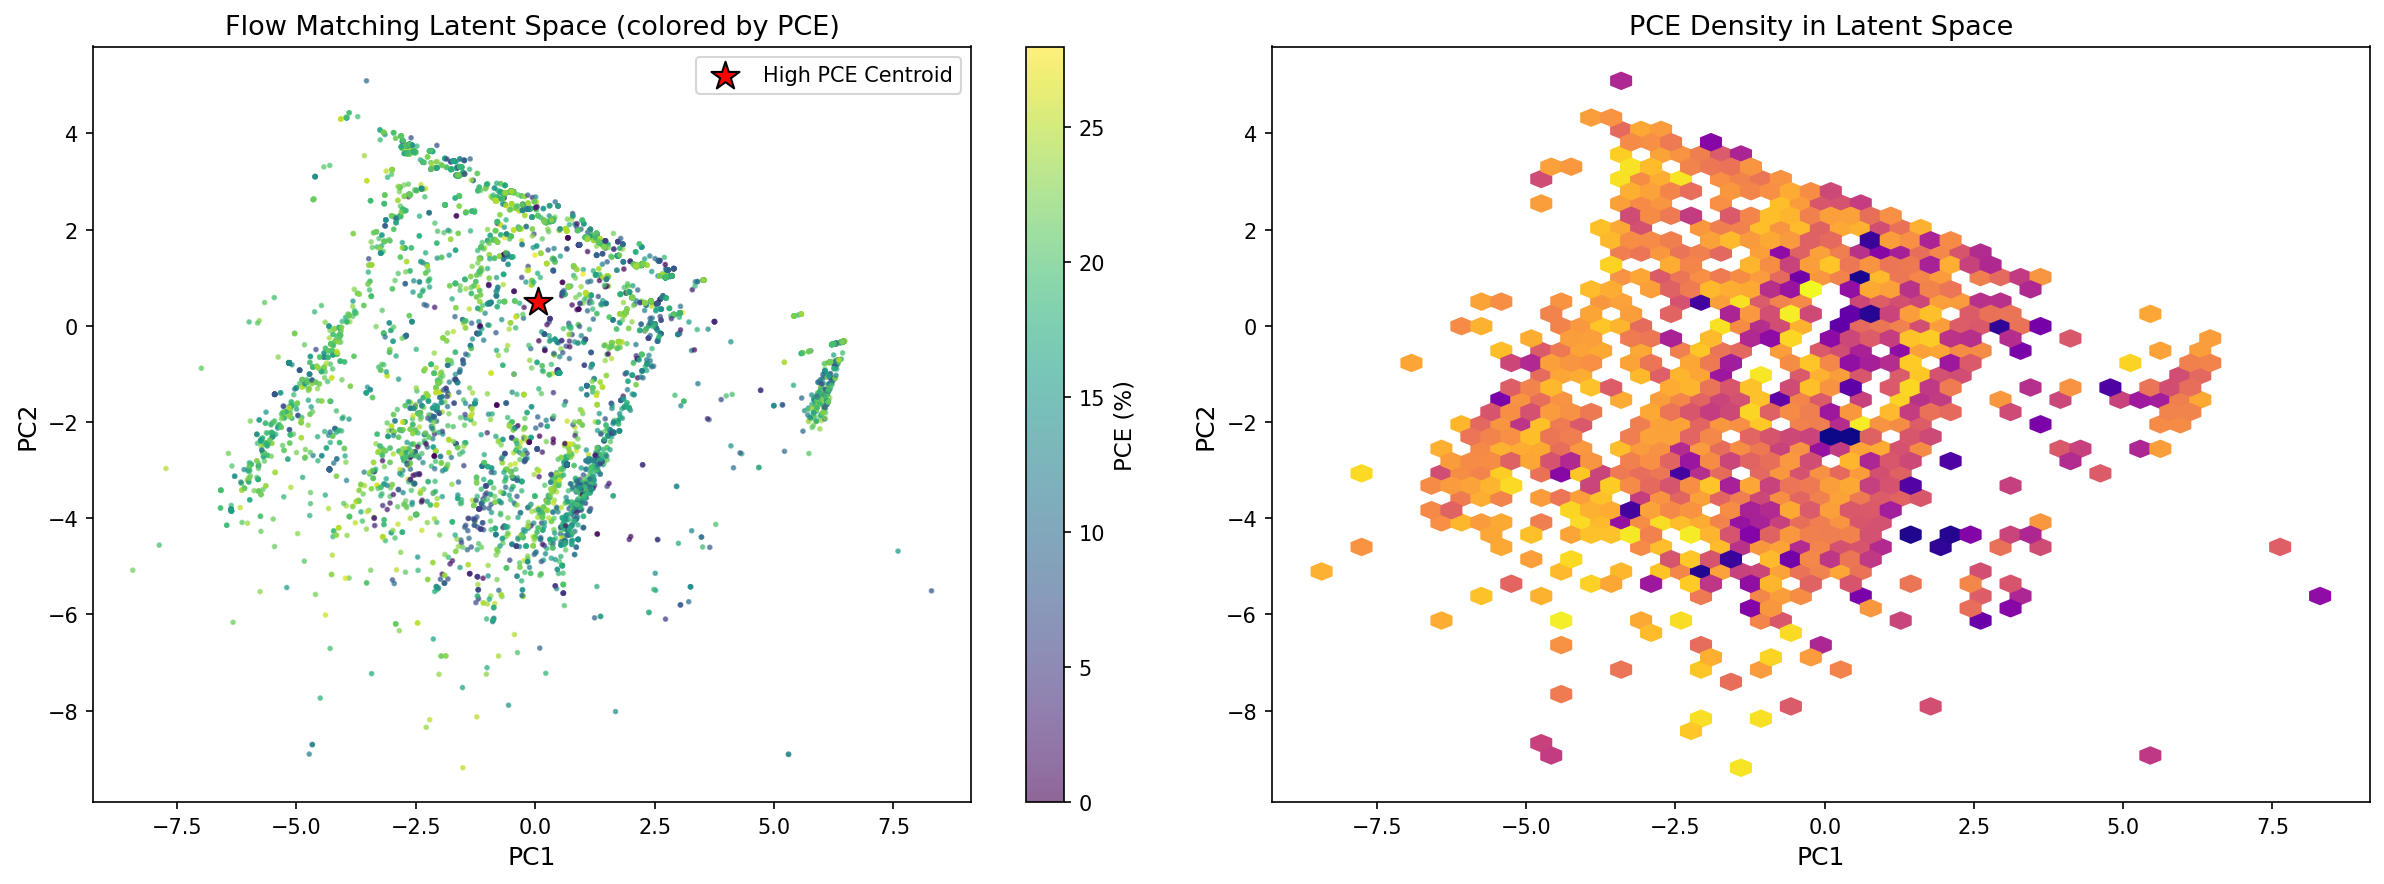

Saved: output1/fm_latent_space.png


In [28]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Figure 1: Latent Space Visualization (PCA 2D projection colored by PCE)
from sklearn.decomposition import PCA as PCA2D

# Project to 2D for visualization
pca_2d = PCA2D(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_aligned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full latent space
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_full, cmap='viridis', 
                          s=3, alpha=0.6, vmin=0, vmax=28)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('Flow Matching Latent Space (colored by PCE)', fontsize=13)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('PCE (%)', fontsize=11)

# Mark high PCE region centroid
high_centroid_2d = pca_2d.transform(high_pce_centroid.reshape(1, -1))
axes[0].scatter(high_centroid_2d[0, 0], high_centroid_2d[0, 1], 
                c='red', s=200, marker='*', edgecolors='black', linewidths=1, 
                label='High PCE Centroid', zorder=5)
axes[0].legend(loc='upper right')

# Plot 2: Density view
from matplotlib.colors import LogNorm
axes[1].hexbin(X_2d[:, 0], X_2d[:, 1], C=y_full, gridsize=50, cmap='plasma', 
               reduce_C_function=np.mean)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('PCE Density in Latent Space', fontsize=13)

plt.tight_layout()
plt.savefig('output1/fm_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output1/fm_latent_space.png")


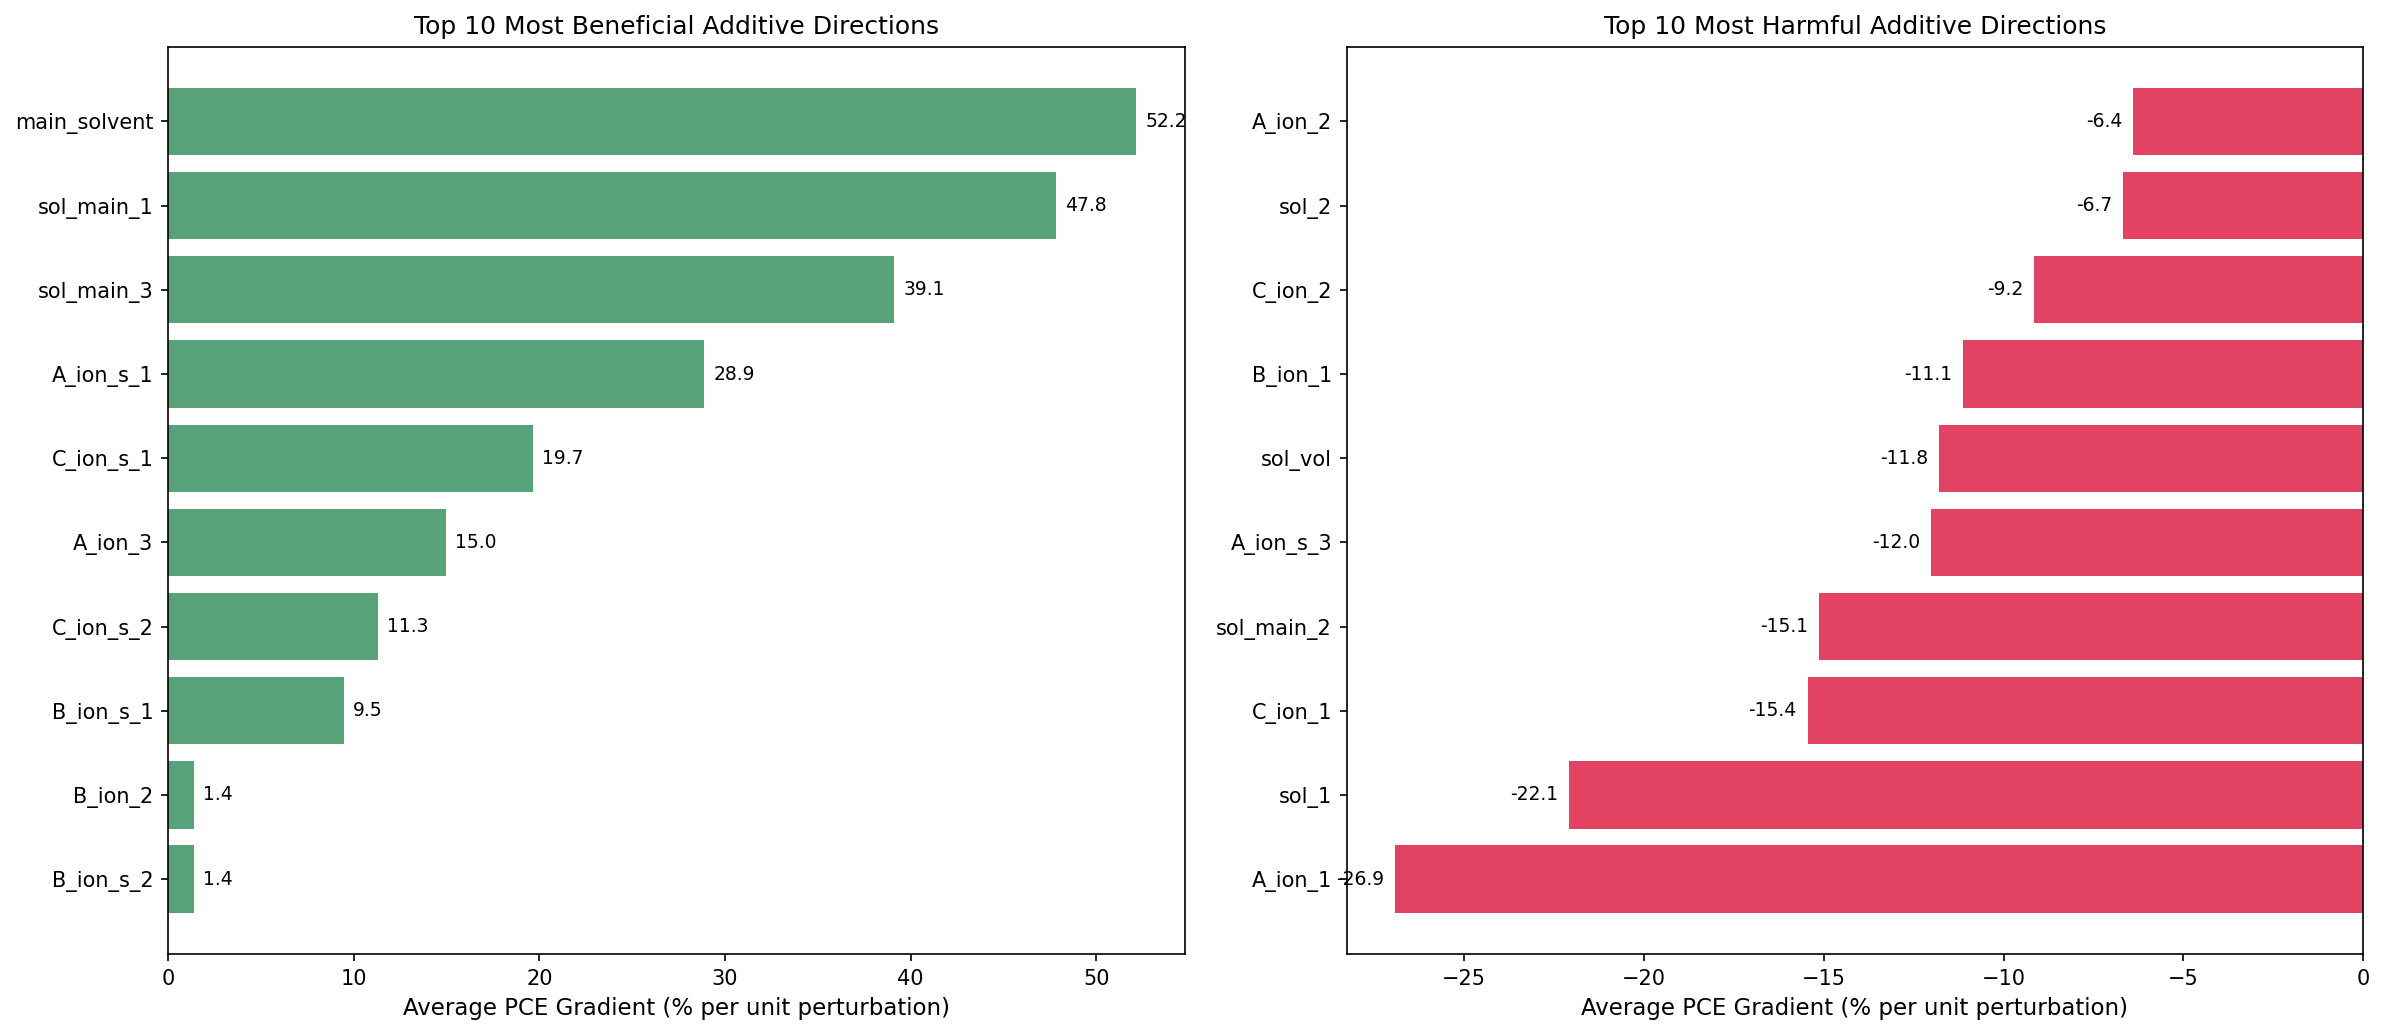

Saved: output1/perturbation_gradient.png


In [29]:
# Figure 2: Perturbation gradient — Top 5 beneficial only, red bars, no caption (see plot_perturbation_gradient.py)
BAR_RED = '#d62728'
fig, ax = plt.subplots(1, 1, figsize=(9, 4.6))

beneficial = sorted_grads[:5]
beneficial_names = [name for name, _ in beneficial]
beneficial_grads = [info['mean_grad'] for _, info in beneficial]

ax.barh(range(len(beneficial_names)), beneficial_grads, color=BAR_RED, alpha=0.88, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(beneficial_names)))
ax.set_yticklabels(beneficial_names, fontsize=10)
ax.set_xlabel('Average PCE Gradient (% per unit perturbation)', fontsize=11)
ax.set_title('Top 5 Most Beneficial Additive Directions', fontsize=12, fontweight='bold')
ax.invert_yaxis()

xmax = max(beneficial_grads) * 1.06
ax.set_xlim(0, xmax)
for i, v in enumerate(beneficial_grads):
    ax.text(v + 0.02 * xmax, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output1/perturbation_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output1/perturbation_gradient.png")


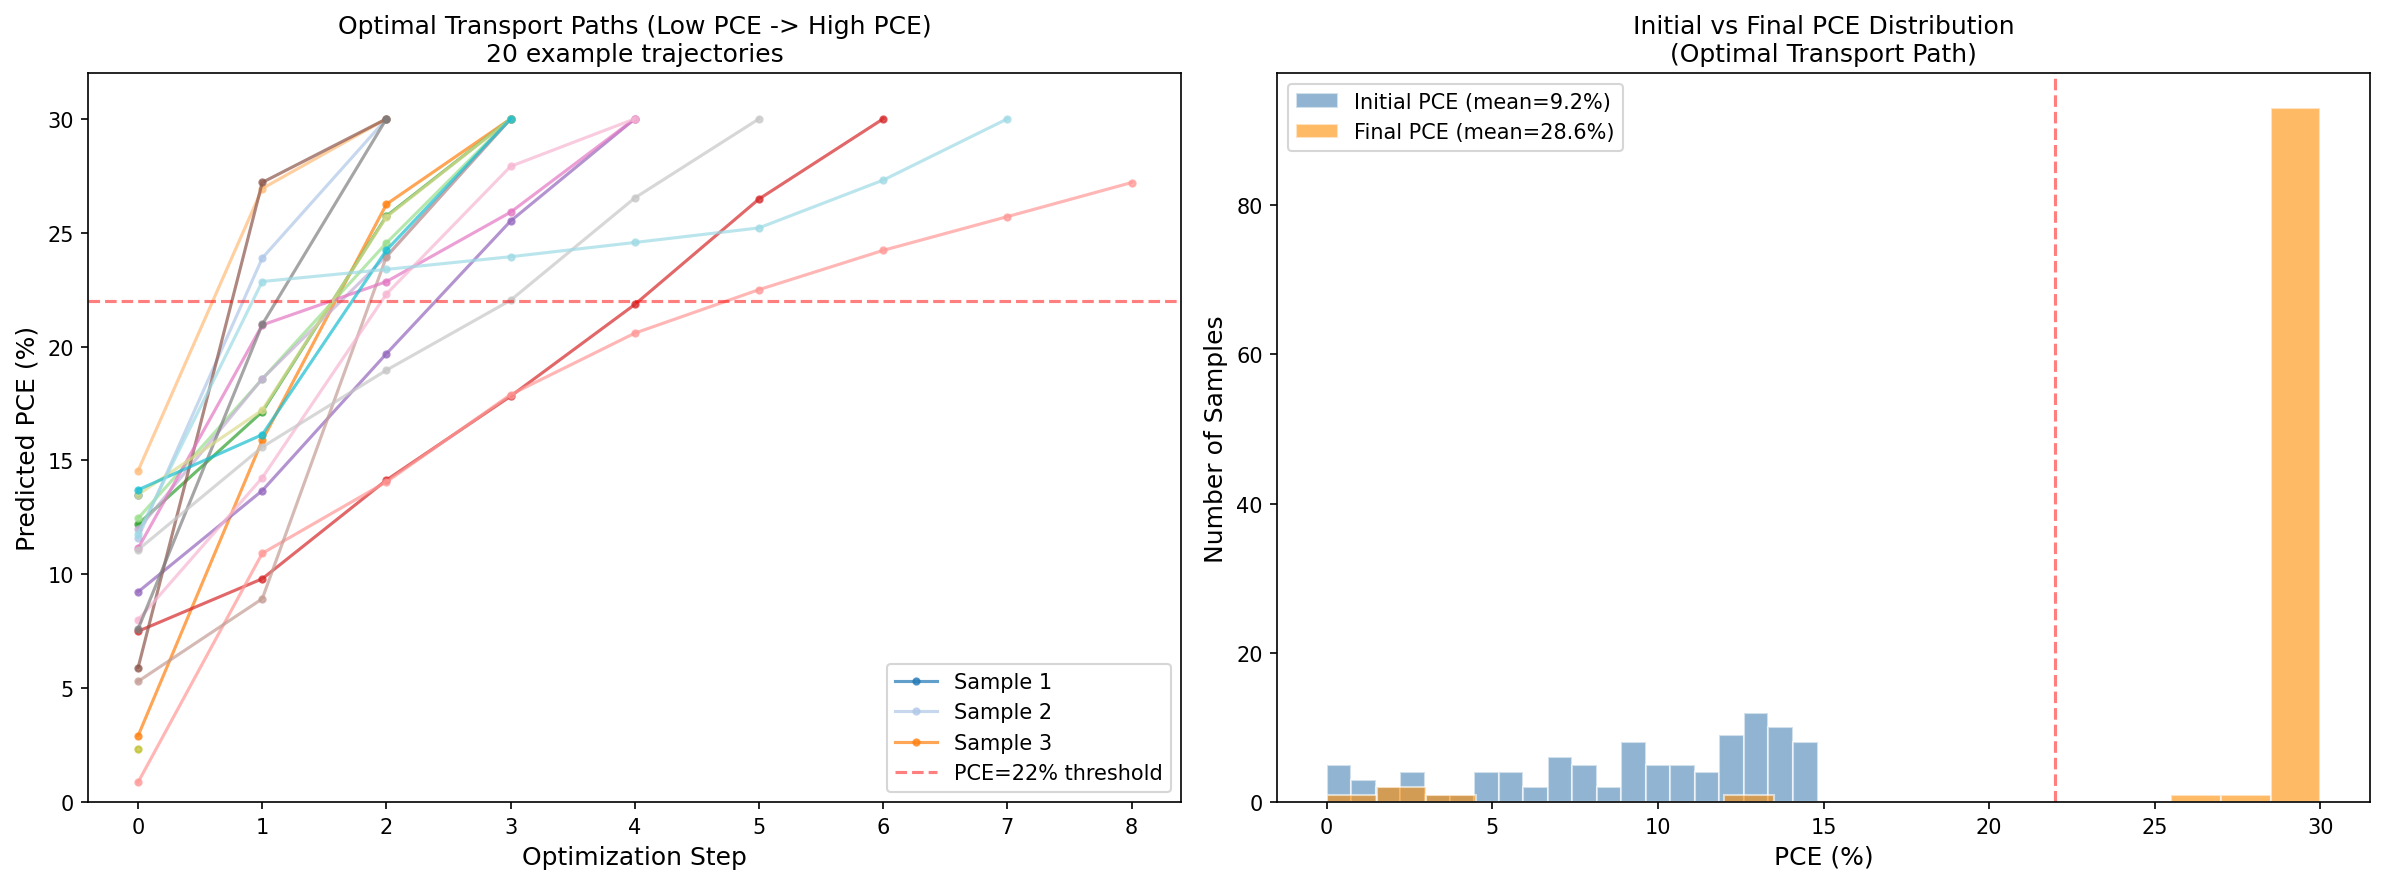

Saved: output1/optimal_transport_paths.png


In [31]:

# Figure 3: Optimal Transport Paths
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Show a few example trajectories
n_show = 20
colors = plt.cm.tab20(np.linspace(0, 1, n_show))

for i in range(min(n_show, len(path_results))):
    traj = path_results[i]['trajectory']
    axes[0].plot(range(len(traj)), traj, '-o', color=colors[i], markersize=3, 
                 linewidth=1.5, alpha=0.7, label=f'Sample {i+1}' if i < 3 else '')

axes[0].set_xlabel('Optimization Step', fontsize=12)
axes[0].set_ylabel('Predicted PCE (%)', fontsize=12)
axes[0].set_title(f'Optimal Transport Paths (Low PCE -> High PCE)\n{n_show} example trajectories', fontsize=12)
axes[0].axhline(y=22, color='red', linestyle='--', alpha=0.5, label='PCE=22% threshold')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 32)

# Plot 2: Distribution of initial vs final PCE
initial_pces = [r['initial_pce'] for r in path_results]
final_pces = [r['final_pce'] for r in path_results]

axes[1].hist(initial_pces, bins=20, alpha=0.6, label=f'Initial PCE (mean={np.mean(initial_pces):.1f}%)', 
             color='steelblue', edgecolor='white')
axes[1].hist(final_pces, bins=20, alpha=0.6, label=f'Final PCE (mean={np.mean(final_pces):.1f}%)', 
             color='darkorange', edgecolor='white')
axes[1].set_xlabel('PCE (%)', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Initial vs Final PCE Distribution\n(Optimal Transport Path)', fontsize=12)
axes[1].axvline(x=22, color='red', linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('output1/optimal_transport_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output1/optimal_transport_paths.png")


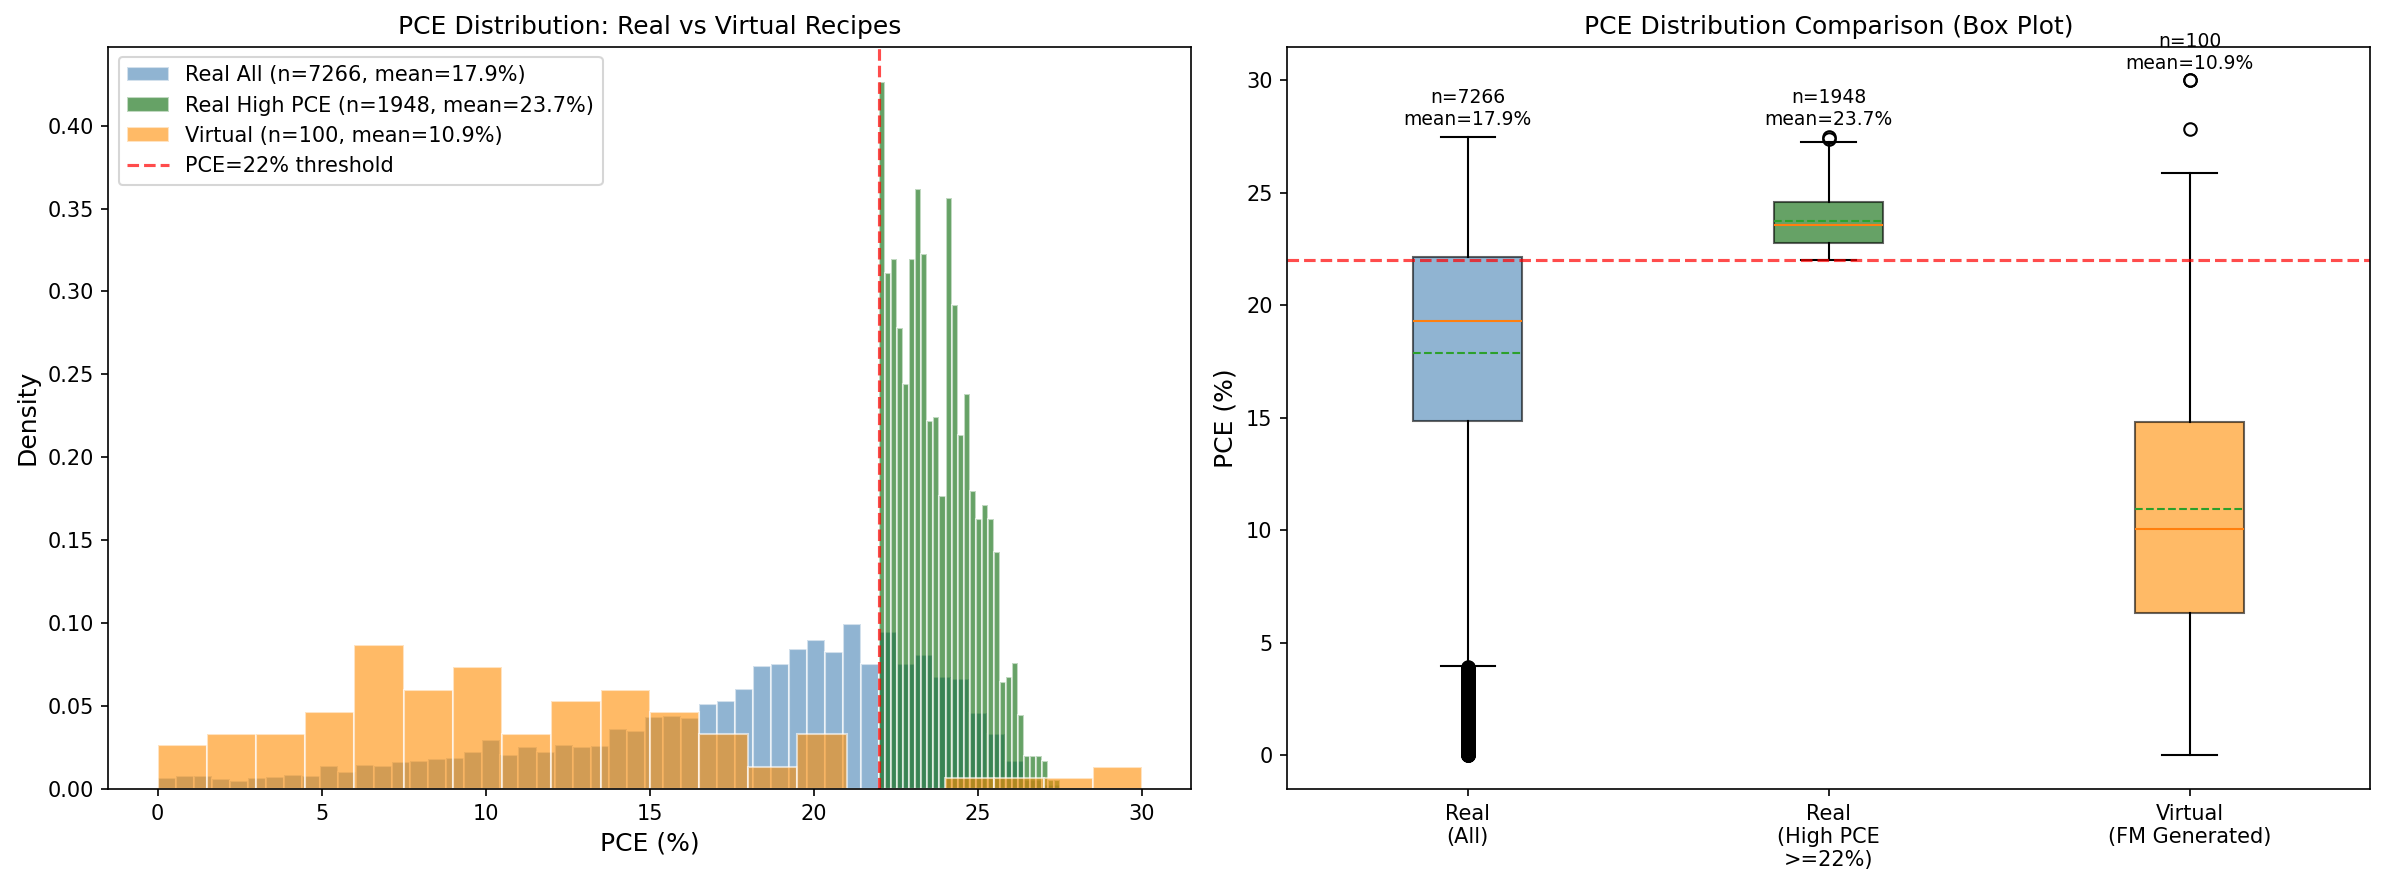

Saved: output1/virtual_vs_real_pce.png


In [32]:

# Figure 4: Virtual vs Real PCE Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full PCE distributions
axes[0].hist(df_valid_reset['PCE'], bins=50, alpha=0.6, density=True,
             label=f'Real All (n={len(df_valid_reset)}, mean={df_valid_reset["PCE"].mean():.1f}%)', 
             color='steelblue', edgecolor='white')
axes[0].hist(high_pce_real['PCE'], bins=30, alpha=0.6, density=True,
             label=f'Real High PCE (n={len(high_pce_real)}, mean={high_pce_real["PCE"].mean():.1f}%)', 
             color='darkgreen', edgecolor='white')
axes[0].hist(virtual_pces, bins=20, alpha=0.6, density=True,
             label=f'Virtual (n={len(virtual_pces)}, mean={virtual_pces.mean():.1f}%)', 
             color='darkorange', edgecolor='white')
axes[0].axvline(x=22, color='red', linestyle='--', alpha=0.7, label='PCE=22% threshold')
axes[0].set_xlabel('PCE (%)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('PCE Distribution: Real vs Virtual Recipes', fontsize=12)
axes[0].legend(loc='upper left')

# Plot 2: Box plot comparison
box_data = [
    df_valid_reset['PCE'].values,
    high_pce_real['PCE'].values,
    virtual_pces
]
box_labels = ['Real\n(All)', 'Real\n(High PCE\n>=22%)', 'Virtual\n(FM Generated)']
bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,
                      showmeans=True, meanline=True)
colors = ['steelblue', 'darkgreen', 'darkorange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].axhline(y=22, color='red', linestyle='--', alpha=0.7)
axes[1].set_ylabel('PCE (%)', fontsize=12)
axes[1].set_title('PCE Distribution Comparison (Box Plot)', fontsize=12)

# Add text annotations
for i, data in enumerate(box_data):
    axes[1].text(i+1, data.max() + 0.5, f'n={len(data)}\nmean={data.mean():.1f}%', 
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('output1/virtual_vs_real_pce.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output1/virtual_vs_real_pce.png")


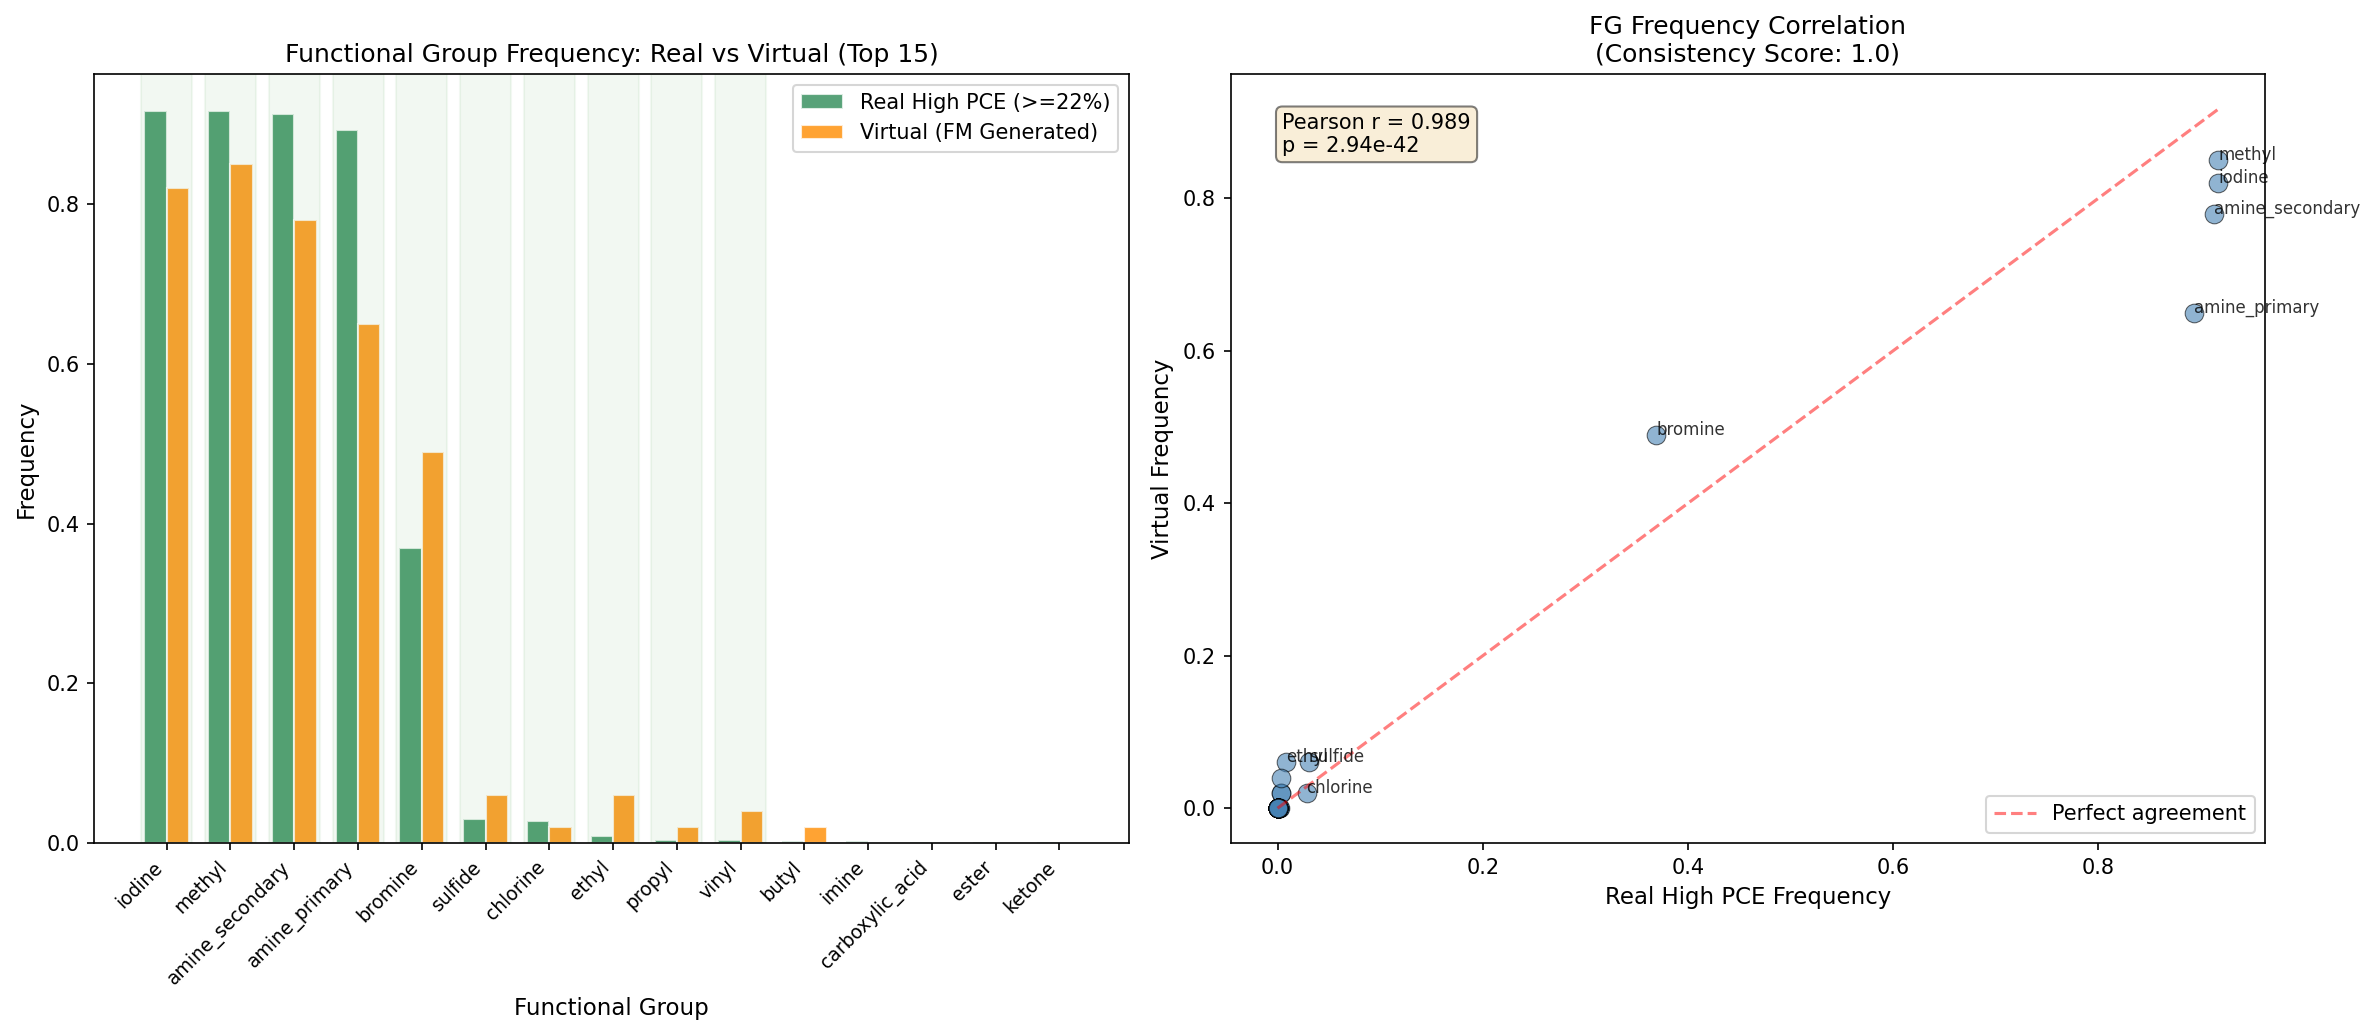

Saved: output1/fg_real_vs_virtual.png


: 

In [ ]:

# Figure 5: Functional Group Frequency Comparison (Real vs Virtual)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Get top 15 FGs for comparison
top_15_fgs = [fg for fg, _ in sorted_real_fg[:15]]
real_freqs_15 = [real_fg_freq[fg] for fg in top_15_fgs]
virtual_freqs_15 = [virtual_fg_freq[fg] for fg in top_15_fgs]

x = np.arange(len(top_15_fgs))
width = 0.35

bars1 = axes[0].bar(x - width/2, real_freqs_15, width, label='Real High PCE (>=22%)', 
                    color='seagreen', alpha=0.8, edgecolor='white')
bars2 = axes[0].bar(x + width/2, virtual_freqs_15, width, label='Virtual (FM Generated)', 
                    color='darkorange', alpha=0.8, edgecolor='white')

axes[0].set_xlabel('Functional Group', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Functional Group Frequency: Real vs Virtual (Top 15)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_15_fgs, rotation=45, ha='right', fontsize=9)
axes[0].legend()

# Add consistency highlight
for i, fg in enumerate(top_15_fgs):
    if fg in overlap:
        axes[0].axvspan(i - 0.4, i + 0.4, alpha=0.05, color='green')

# Plot 2: Scatter plot of real vs virtual frequencies
all_fgs = list(FG_PATTERNS.keys())
all_real_freqs = [real_fg_freq[fg] for fg in all_fgs]
all_virtual_freqs = [virtual_fg_freq[fg] for fg in all_fgs]

axes[1].scatter(all_real_freqs, all_virtual_freqs, s=80, alpha=0.6, c='steelblue', edgecolors='black', linewidths=0.5)

# Add diagonal line
max_val = max(max(all_real_freqs), max(all_virtual_freqs))
axes[1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect agreement')

# Annotate key points
for fg in top_15_fgs[:8]:
    axes[1].annotate(fg, (real_fg_freq[fg], virtual_fg_freq[fg]), 
                    fontsize=8, ha='left', alpha=0.8)

axes[1].set_xlabel('Real High PCE Frequency', fontsize=11)
axes[1].set_ylabel('Virtual Frequency', fontsize=11)
axes[1].set_title(f'FG Frequency Correlation\n(Consistency Score: {consistency_score:.1f})', fontsize=12)
axes[1].legend()

# Compute correlation
from scipy.stats import pearsonr
corr, pval = pearsonr(all_real_freqs, all_virtual_freqs)
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}\np = {pval:.2e}', 
            transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('output1/fg_real_vs_virtual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output1/fg_real_vs_virtual.png")
